# Strain Simulation with FEniCSx (dolfinx)

Modern FEniCSx port of `G-Factor Simulation.ipynb`. Reads the mesh in XDMF format. The mesh files are produced from the Gmsh geometry with:

```bash
conda activate fenicsx
gmsh -3 Rooney3D.geo -o Rooney3D.msh
python gmsh_to_xdmf.py Rooney3D.msh rooney3d
```

(If starting from legacy FEniCS XML mesh files instead, use `legacy_xml_to_xdmf.py` in the `fenics` env and set `GRID_NAME = "mesh"` below.)

Run this notebook in the `fenicsx` environment (`conda activate fenicsx`).

# Initialization

## Imports

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpi4py import MPI
from petsc4py import PETSc

import ufl
import dolfinx.mesh
import dolfinx.fem.petsc
from dolfinx import fem, geometry
from dolfinx.io import XDMFFile

## Configuration

In [2]:
# Paths to the mesh files (produced by gmsh_to_xdmf.py from the Gmsh mesh,
# or by legacy_xml_to_xdmf.py from legacy FEniCS XML files)
MESH_XDMF = "rooney3d_medium.xdmf"
SUBDOMAINS_XDMF = "rooney3d_medium_subdomains.xdmf"
BOUNDARIES_XDMF = "rooney3d_medium_boundaries.xdmf"
# XDMF grid name: "Grid" for meshio-produced files, "mesh" for legacy-dolfin-produced ones
GRID_NAME = "Grid"

# Where simulation results (displacement checkpoint + parameters) are saved
RESULTS_DIR = "Simulation Results"
RUN_NAME = None  # set a string to override the default timestamped folder name

# z-coordinate convention for all settings, plots and exports below:
#   z = -z_mesh - 13
# so the 16 nm Ge well spans z = 42 (top edge) to z = 58 (bottom edge).
def z_to_mesh(z):
    """Map the exported z-coordinate to the mesh's internal z-coordinate."""
    return -np.asarray(z, dtype=float) - 13.0

# Grid extents for the 2D slice exports/plots (match the geometry's xy footprint)
X_RANGE = (-500.0, 500.0)
Y_RANGE = (-410.0, 590.0)
Z_PLANE = 50.0           # 2D slice at the middle of the Ge well
GRID_2D = 400           # points per axis for 2D CSV exports

# Grid for the 3D CSV exports (covers the germanium well)
Z3_RANGE = (42.0, 58.0)
GRID_3D = (300, 300, 30)

# Coordinate convention note: all CSV exports from this notebook store
# coordinates with the shift ALREADY APPLIED to the data (x and y shifted,
# z stored in the exported convention z = -z_mesh - 13). Downstream
# notebooks reading those CSVs must NOT shift the data again; only raw-frame
# quantities (e.g. hard-coded gate coordinates) still need the shift.
# xy-coordinate shift applied to DATA at export time and to DATA and GATES
# at plot time (exported_x = mesh_x + SHIFT_X, exported_y = mesh_y + SHIFT_Y)
SHIFT_X = -1.25
SHIFT_Y = -108.05

## Importing Mesh

In [3]:
with XDMFFile(MPI.COMM_WORLD, MESH_XDMF, "r") as xdmf:
    mesh = xdmf.read_mesh(name=GRID_NAME)

tdim = mesh.topology.dim
fdim = tdim - 1
mesh.topology.create_entities(fdim)
mesh.topology.create_connectivity(fdim, tdim)

# Read the subdomain (material) and boundary tags
with XDMFFile(MPI.COMM_WORLD, SUBDOMAINS_XDMF, "r") as xdmf:
    subdomains = xdmf.read_meshtags(mesh, name=GRID_NAME, attribute_name="subdomains")
with XDMFFile(MPI.COMM_WORLD, BOUNDARIES_XDMF, "r") as xdmf:
    boundaries = xdmf.read_meshtags(mesh, name=GRID_NAME, attribute_name="boundaries")

print("Mesh:", mesh.topology.index_map(tdim).size_global, "cells")
print("Material tags:", np.unique(subdomains.values))
print("Boundary tags:", np.unique(boundaries.values))

Mesh: 727475 cells
Material tags: [295 296 297 298]
Boundary tags: [299 300]


## Helper Functions

In [4]:
def evaluate_at_points(func, points):
    """Evaluate a dolfinx Function at points of shape (N, 3).

    Returns an (N, value_size) array; NaN for points outside the mesh.
    """
    points = np.asarray(points, dtype=np.float64)
    tree = geometry.bb_tree(mesh, tdim)
    candidates = geometry.compute_collisions_points(tree, points)
    colliding = geometry.compute_colliding_cells(mesh, candidates, points)
    offsets = colliding.offsets
    has_cell = (offsets[1:] - offsets[:-1]) > 0
    idx = np.nonzero(has_cell)[0]
    first_cell = colliding.array[offsets[:-1][has_cell]]
    evaluated = func.eval(points[idx], first_cell).reshape(len(idx), -1)
    out = np.full((len(points), evaluated.shape[1]), np.nan)
    out[idx] = evaluated
    return out


def eps(v):
    """Symmetric gradient (strain tensor)."""
    return ufl.sym(ufl.grad(v))


def make_grid(x_values, y_values, z_coord):
    """Grid of points in the xy-plane at the given z-coordinate."""
    X, Y = np.meshgrid(x_values, y_values)
    points = np.column_stack([X.ravel(), Y.ravel(),
                              np.full(X.size, float(z_to_mesh(z_coord)))])
    return X, Y, points

# Solving

## Define Material Parameters

In [5]:
# Material properties for each physical region (subdomain tag)
MATERIAL_PROPS = {
    298: {"lam": 49.0,  "mu": 68.8, "alpha": 0.76e-6},   # Ge
    296: {"lam": 63.3,  "mu": 68.5, "alpha": 3.30e-6},   # Al2O3
    295: {"lam": 61.37, "mu": 30.9, "alpha": 14.16e-6},  # Al
    297: {"lam": 52.2,  "mu": 71.1, "alpha": 4.37e-6},   # Ge0.8Si0.2
}

# DG0 function space holds one constant value per cell
V0 = fem.functionspace(mesh, ("DG", 0))


def material_function(name):
    """Build a DG0 function with the given material property on each region."""
    func = fem.Function(V0, name=name)
    for tag, props in MATERIAL_PROPS.items():
        func.x.array[subdomains.find(tag)] = props[name]
    func.x.scatter_forward()
    return func


lam = material_function("lam")      # first Lame parameter
mu = material_function("mu")        # second Lame parameter
alpha = material_function("alpha")  # thermal expansion coefficient

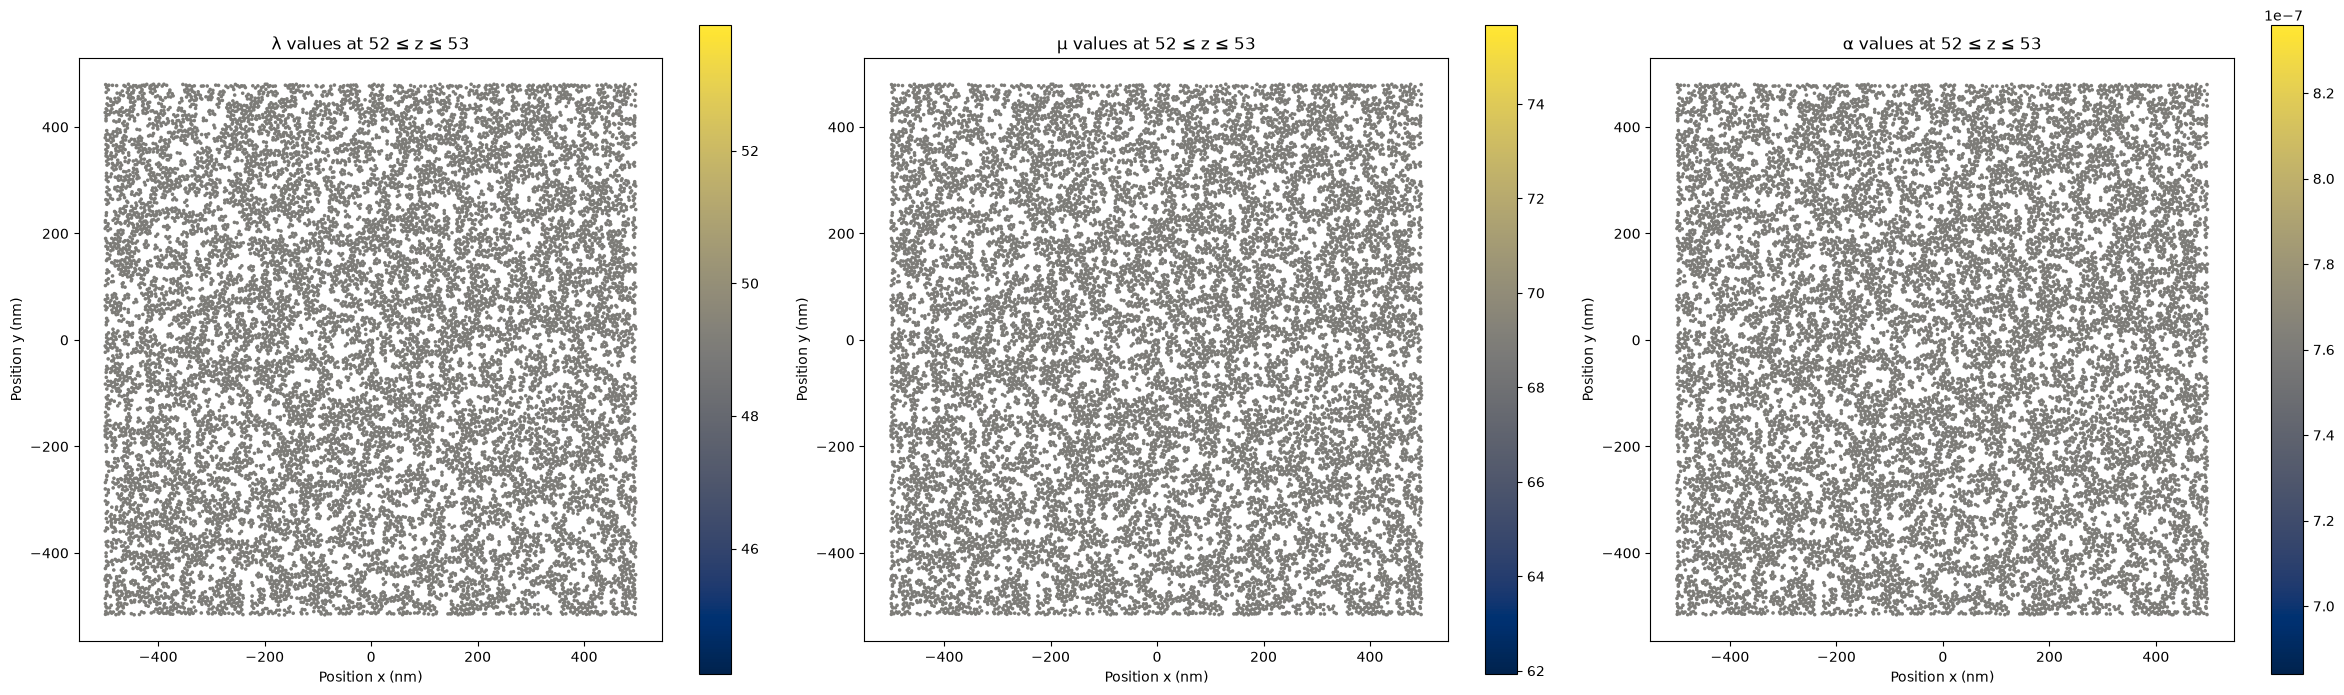

In [6]:
# Sanity check: scatter plot of the material parameters on a z-slice of cell midpoints
z_min, z_max = 52, 53  # adjust to the range you want to inspect (exported z convention)

num_cells = mesh.topology.index_map(tdim).size_local
mids = dolfinx.mesh.compute_midpoints(mesh, tdim, np.arange(num_cells, dtype=np.int32))
z_mids = -mids[:, 2] - 13
z_filter = (z_mids >= z_min) & (z_mids <= z_max)

fig, axs = plt.subplots(1, 3, figsize=(24, 7))
for ax, func, title in zip(axs, [lam, mu, alpha], ["\u03bb", "\u03bc", "\u03b1"]):
    # Shift the DATA coordinates (x and y) from the raw mesh frame into the
    # exported frame for display; the data itself is unshifted here.
    sc = ax.scatter(mids[z_filter, 0] + SHIFT_X, mids[z_filter, 1] + SHIFT_Y,
                    c=func.x.array[z_filter], cmap="cividis", marker=".", s=10)
    fig.colorbar(sc, ax=ax)
    ax.set_title(f"{title} values at {z_min} \u2264 z \u2264 {z_max}")
    ax.set_xlabel("Position x (nm)")
    ax.set_ylabel("Position y (nm)")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Solve Thermal Equilibrium Problem

In [9]:
# Function space for temperature
VT = fem.functionspace(mesh, ("Lagrange", 1))

T_ = ufl.TestFunction(VT)
dT = ufl.TrialFunction(VT)

# Steady-state heat conduction with no internal heat generation
aT = ufl.dot(ufl.grad(dT), ufl.grad(T_)) * ufl.dx
LT = fem.Constant(mesh, PETSc.ScalarType(0.0)) * T_ * ufl.dx

# Temperature fixed at 280 K on the base (299) and top (300) boundaries
T_BC1 = fem.dirichletbc(fem.Constant(mesh, PETSc.ScalarType(280.0)),
                        fem.locate_dofs_topological(VT, fdim, boundaries.find(299)), VT)
T_BC2 = fem.dirichletbc(fem.Constant(mesh, PETSc.ScalarType(280.0)),
                        fem.locate_dofs_topological(VT, fdim, boundaries.find(300)), VT)

thermal_problem = fem.petsc.LinearProblem(
    aT, LT, bcs=[T_BC1, T_BC2],
    petsc_options_prefix="thermal_",
    petsc_options={"ksp_type": "gmres", "pc_type": "hypre"},
)
Delta_T = thermal_problem.solve()
Delta_T.name = "Temperature increase"
print("dT range:", Delta_T.x.array.min(), "to", Delta_T.x.array.max())

dT range: 279.98969666200804 to 280.005830059498


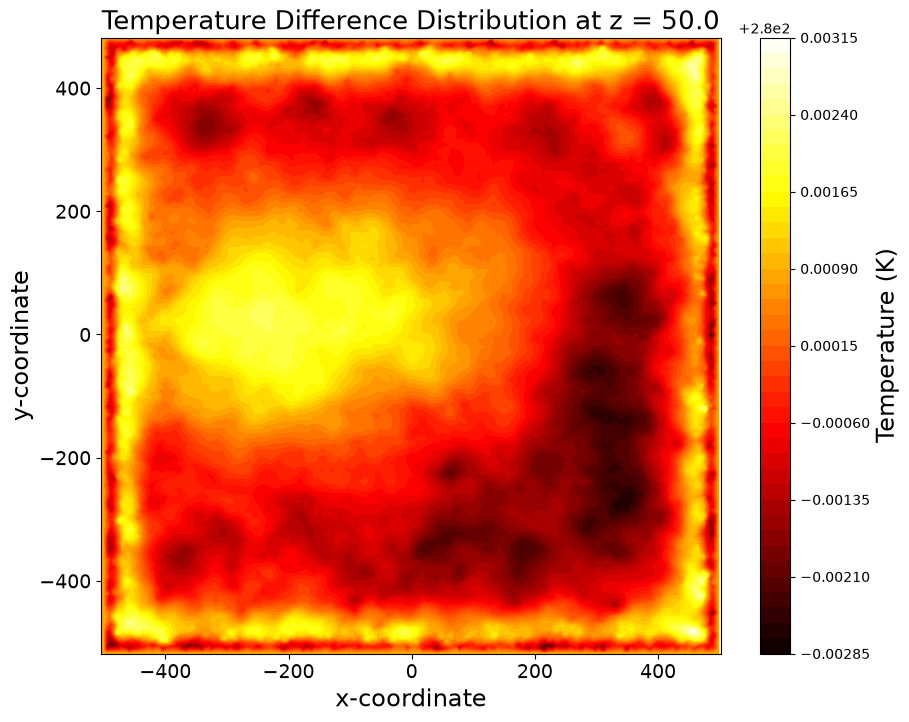

In [10]:
# Plot the temperature distribution on a z-parallel plane (exported z convention),
# using direct point evaluation like the displacement/strain plots below
Z_PLANE_T = 50.0  # middle of the Ge well

x_lin = np.linspace(*X_RANGE, 400)
y_lin = np.linspace(*Y_RANGE, 400)
X, Y, points = make_grid(x_lin, y_lin, Z_PLANE_T)
T_values = evaluate_at_points(Delta_T, points)[:, 0].reshape(X.shape)

plt.figure(figsize=(10, 8))
# Shift the DATA coordinates (x and y) into the exported frame for display
contour = plt.contourf(X + SHIFT_X, Y + SHIFT_Y, T_values, levels=50, cmap="hot")
cbar = plt.colorbar(contour, label="Temperature (K)")
cbar.ax.set_ylabel("Temperature (K)", fontsize=17)
plt.title(f"Temperature Difference Distribution at z = {Z_PLANE_T}", fontsize=19)
plt.xlabel("x-coordinate", fontsize=17)
plt.ylabel("y-coordinate", fontsize=17)
plt.axis("equal")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Solve Strain Problem

In [11]:
def sigma(v, dT):
    """Stress tensor including thermal expansion effects."""
    I = ufl.Identity(tdim)
    thermal_expansion = alpha * (3 * lam + 2 * mu) * dT
    return (lam * ufl.tr(eps(v)) - thermal_expansion) * I + 2.0 * mu * eps(v)

In [12]:
# Vector function space for the displacement field
Vu = fem.functionspace(mesh, ("Lagrange", 2, (tdim,)))

du = ufl.TrialFunction(Vu)
u_ = ufl.TestFunction(Vu)

# No external body forces
f = fem.Constant(mesh, np.zeros(tdim, dtype=PETSc.ScalarType))

# Weak form of the internal energy
Wint = ufl.inner(sigma(du, Delta_T), eps(u_)) * ufl.dx
aM = ufl.lhs(Wint)
LM = ufl.rhs(Wint) + ufl.inner(f, u_) * ufl.dx

# Fixed displacement at the base (299) and top (300) boundaries
zero_displacement = np.zeros(tdim, dtype=PETSc.ScalarType)
U_BC1 = fem.dirichletbc(zero_displacement,
                        fem.locate_dofs_topological(Vu, fdim, boundaries.find(299)), Vu)
U_BC2 = fem.dirichletbc(zero_displacement,
                        fem.locate_dofs_topological(Vu, fdim, boundaries.find(300)), Vu)

# CG + BoomerAMG with nodal coarsening: much lower memory than gmres+default
# hypre for vector-valued elasticity (the matrix is symmetric positive definite,
# so CG applies; nodal coarsening keeps the AMG hierarchy small).
elasticity_problem = fem.petsc.LinearProblem(
    aM, LM, bcs=[U_BC1, U_BC2],
    petsc_options_prefix="elasticity_",
    petsc_options={"ksp_type": "cg", "pc_type": "hypre",
                   "pc_hypre_boomeramg_nodal_coarsen": 6,
                   "pc_hypre_boomeramg_vec_interp_variant": 3},
)
u = elasticity_problem.solve()
u.name = "Displacement"
print("Displacement range:", u.x.array.min(), "to", u.x.array.max())

Displacement range: -0.0709938737239884 to 0.06698085645906451


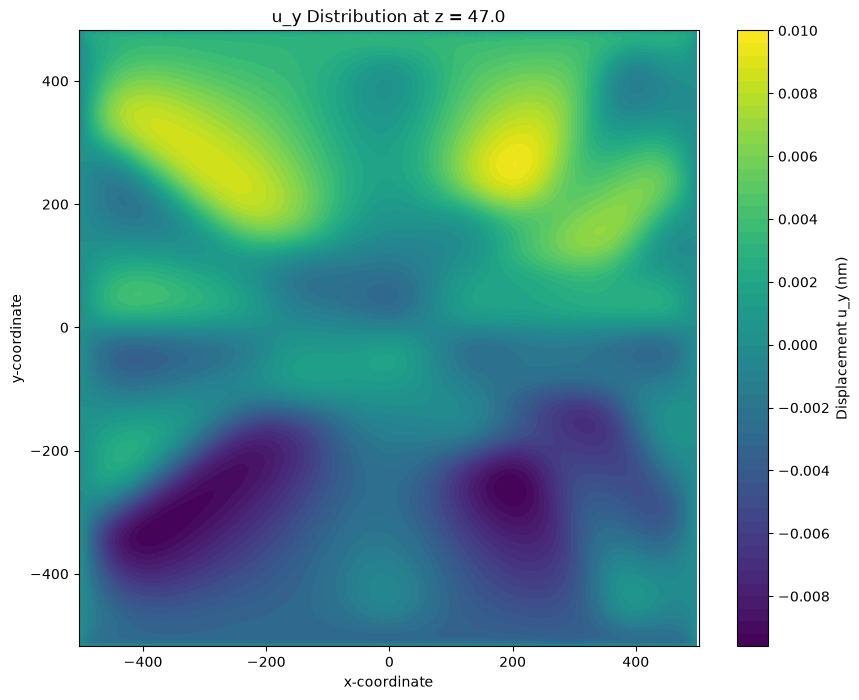

In [13]:
# Plot the u_y component on the 2D slice plane
x_lin = np.linspace(*X_RANGE, 500)
y_lin = np.linspace(*Y_RANGE, 500)
X, Y, points = make_grid(x_lin, y_lin, Z_PLANE)
Uy = evaluate_at_points(u, points)[:, 1].reshape(X.shape)

plt.figure(figsize=(10, 8))
# Shift the DATA coordinates (x and y) into the exported frame for display
contour = plt.contourf(X + SHIFT_X, Y + SHIFT_Y, Uy, levels=50, cmap="viridis")
plt.colorbar(contour, label="Displacement u_y (nm)")
plt.title(f"u_y Distribution at z = {Z_PLANE}")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.axis("equal")
plt.show()

## Save Simulation Result

In [14]:
from datetime import datetime
import shutil

run_dir = os.path.join(RESULTS_DIR, RUN_NAME or datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
os.makedirs(run_dir, exist_ok=True)

# Exact checkpoint: raw degree-of-freedom vectors of the CG1 temperature
# and CG2 displacement fields
np.save(os.path.join(run_dir, "temperature.npy"), Delta_T.x.array)
np.save(os.path.join(run_dir, "displacement.npy"), u.x.array)

# Copy the mesh files so the run is self-contained
for path in [MESH_XDMF, SUBDOMAINS_XDMF, BOUNDARIES_XDMF]:
    base = os.path.splitext(path)[0]
    for ext in [".xdmf", ".h5"]:
        shutil.copy(base + ext, os.path.join(run_dir, os.path.basename(base + ext)))

# Simulation parameters and metadata
params = {
    "date": datetime.now().isoformat(timespec="seconds"),
    "dolfinx_version": dolfinx.__version__,
    "mesh_files": {"mesh": MESH_XDMF, "subdomains": SUBDOMAINS_XDMF,
                   "boundaries": BOUNDARIES_XDMF, "grid_name": GRID_NAME},
    "num_cells": mesh.topology.index_map(tdim).size_global,
    "material_props": MATERIAL_PROPS,
    "thermal_bc": {"temperature_K": 280.0, "boundary_tags": [299, 300]},
    "displacement_bc": {"value": [0.0, 0.0, 0.0], "boundary_tags": [299, 300]},
    "solver": {"ksp_type": "cg", "pc_type": "hypre",
               "pc_hypre_boomeramg_nodal_coarsen": 6,
               "pc_hypre_boomeramg_vec_interp_variant": 3},
    "displacement_space": {"family": "Lagrange", "degree": 2},
    "z_convention": "z = -z_mesh - 13 (Ge well: z=42 top edge, z=58 bottom edge)",
    "xy_shift": {"shift_x": SHIFT_X, "shift_y": SHIFT_Y},
    "grid_config": {"X_RANGE": X_RANGE, "Y_RANGE": Y_RANGE, "Z_PLANE": Z_PLANE,
                    "GRID_2D": GRID_2D, "Z3_RANGE": Z3_RANGE, "GRID_3D": GRID_3D},
}
with open(os.path.join(run_dir, "parameters.json"), "w") as fp:
    json.dump(params, fp, indent=2, default=str)

print("Saved simulation result to", run_dir)

Saved simulation result to Simulation Results/2026-09-07_10-08-24


# Post-Processing

In [5]:
# Set to a saved run directory to load its result instead of solving,
# e.g. LOAD_RUN = "Simulation Results/2026-09-05_18-40-00"
LOAD_RUN = "Simulation Results/2026-09-07_10-08-24"

if LOAD_RUN is not None:
    with open(os.path.join(LOAD_RUN, "parameters.json")) as fp:
        saved_params = json.load(fp)
    print("Loaded run from", saved_params["date"])

    mesh_file = os.path.join(LOAD_RUN, os.path.basename(saved_params["mesh_files"]["mesh"]))
    with XDMFFile(MPI.COMM_WORLD, mesh_file, "r") as xdmf:
        mesh = xdmf.read_mesh(name=saved_params["mesh_files"]["grid_name"])
    tdim = mesh.topology.dim
    mesh.topology.create_entities(tdim - 1)

    Vu = fem.functionspace(mesh, ("Lagrange", 2, (tdim,)))
    u = fem.Function(Vu, name="Displacement")
    u.x.array[:] = np.load(os.path.join(LOAD_RUN, "displacement.npy"))
    u.x.scatter_forward()
    print("Loaded displacement:", saved_params["num_cells"], "cells,",
          "u range", u.x.array.min(), "to", u.x.array.max())

Loaded run from 2026-09-07T10:08:26
Loaded displacement: 727475 cells, u range -0.0709938737239884 to 0.06698085645906451


## Strain Components

In [6]:
strain_tensor = eps(u)

# Scalar CG1 space for projected strain components
V_scalar = fem.functionspace(mesh, ("Lagrange", 1))


def project_scalar(expr, name):
    """Project a UFL expression onto the scalar CG1 space."""
    u_p = ufl.TrialFunction(V_scalar)
    v_p = ufl.TestFunction(V_scalar)
    projection = fem.petsc.LinearProblem(
        u_p * v_p * ufl.dx, expr * v_p * ufl.dx,
        petsc_options_prefix="project_" + name,
        petsc_options={"ksp_type": "cg", "pc_type": "jacobi"},
    )
    func = projection.solve()
    func.name = name
    return func


# Strain components used downstream
strain_components = {
    "yy-xx": project_scalar(strain_tensor[1, 1] - strain_tensor[0, 0], "Strain_YY_m_XX"),
    "xz": project_scalar(strain_tensor[0, 2], "Strain_XZ"),
    "yz": project_scalar(strain_tensor[1, 2], "Strain_YZ"),
    "xy": project_scalar(strain_tensor[0, 1], "Strain_XY"),
    "zz": project_scalar(strain_tensor[2, 2], "Strain_ZZ"),
    "yy+xx": project_scalar(strain_tensor[1, 1] + strain_tensor[0, 0], "Strain_YY_p_XX"),
    "xx+yy+zz": project_scalar(strain_tensor[0, 0] + strain_tensor[1, 1] + strain_tensor[2, 2],
                               "Strain_XX_p_YY_p_ZZ"),
    "zz-0.5(xx+yy)": project_scalar(strain_tensor[2, 2] - 0.5 * (strain_tensor[0, 0] + strain_tensor[1, 1]),
                                    "Strain_ZZ_m_05_XX_p_YY"),
}

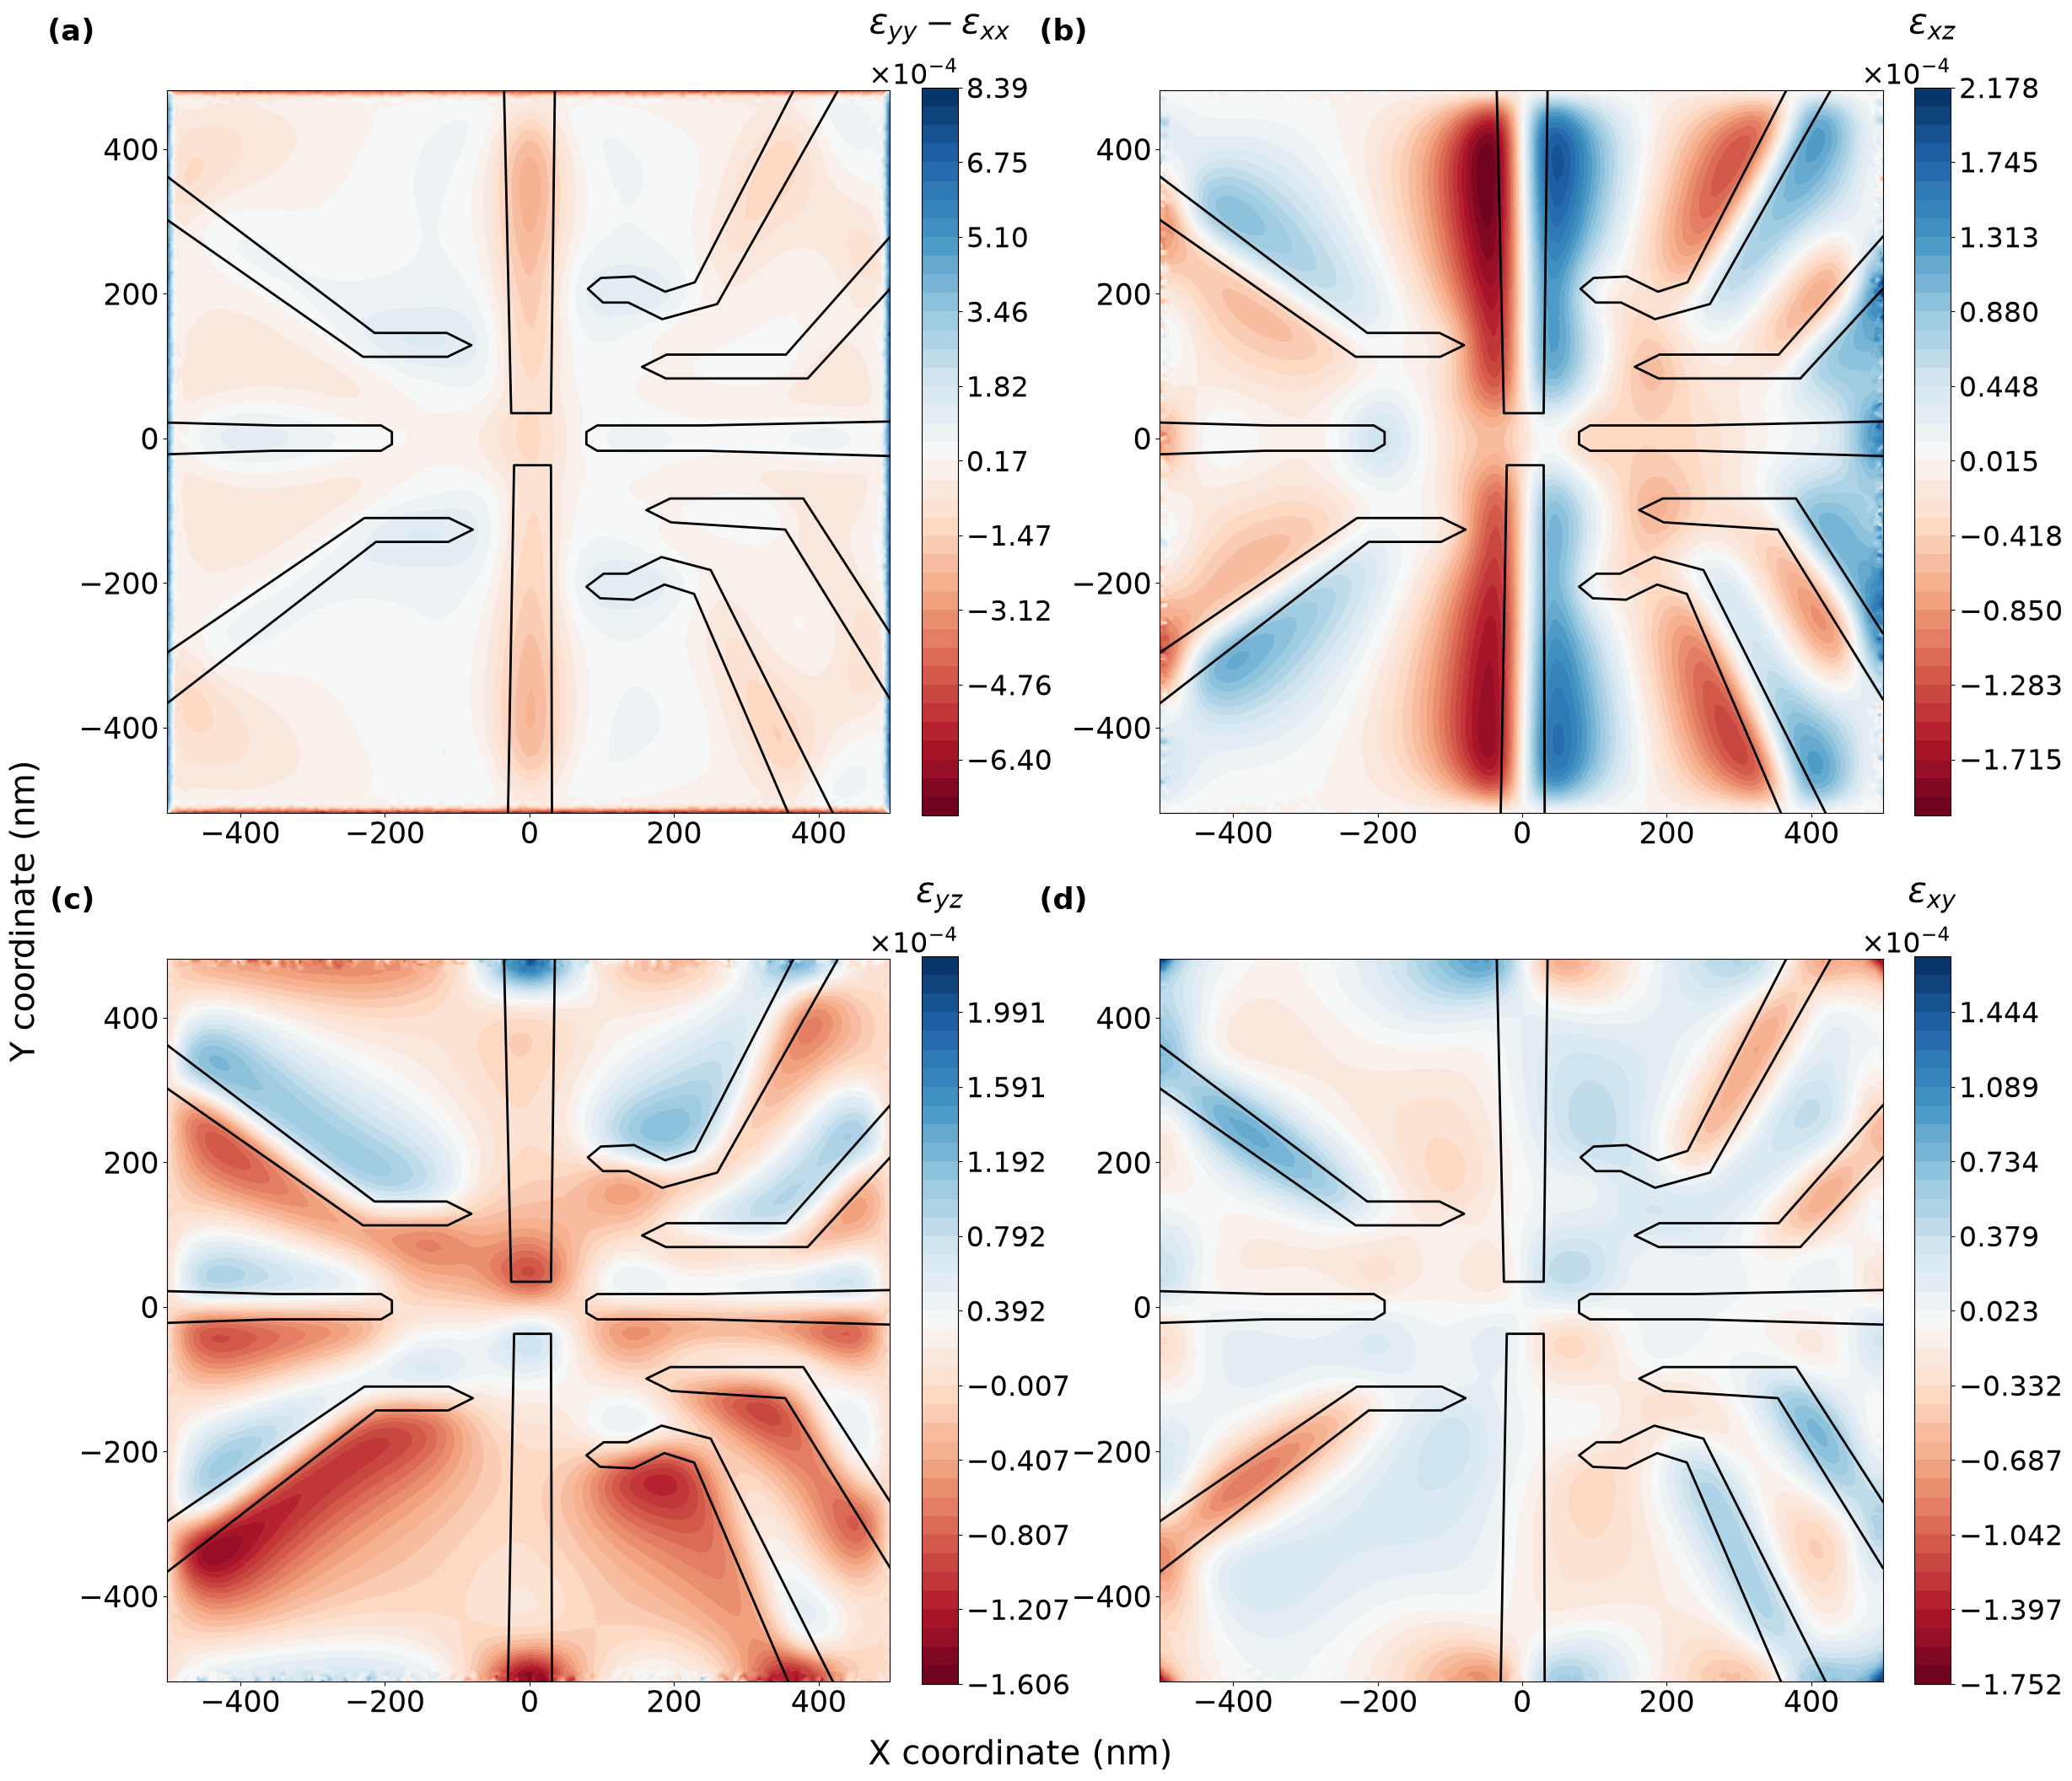

In [7]:
# Plot the 4 shear/diagonal strain components with the standard 2x2 layout
from matplotlib.ticker import ScalarFormatter

# ==========================
# Configuration Variables
# ==========================

# Axis properties
AXIS_TICK_SIZE = 25        # Size of the axis ticks
AXIS_LABEL_SIZE = 29       # Size of the axis labels

# Colorbar properties
COLORBAR_LABEL_SIZE = 30   # Size of the colorbar label
COLORBAR_TICK_SIZE = 24    # Size of the colorbar ticks
COLORBAR_OFFSET_TEXT_SIZE = 24  # Size of the colorbar scientific notation (e.g., 10^-4)

# Subplot label properties
SUBPLOT_LABEL_SIZE = 25
SUBPLOT_LABEL_FONTWEIGHT = 'bold'

# ==========================
# Plotting Function
# ==========================

def format_colorbar(cbar, label):
    cbar.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    if cbar.ax.yaxis.offsetText:
        cbar.ax.yaxis.offsetText.set_fontsize(COLORBAR_OFFSET_TEXT_SIZE)
    cbar.ax.set_title(label, fontsize=COLORBAR_LABEL_SIZE, pad=20, loc='center')

# ==========================
# Define Gates Coordinates
# ==========================

coordinate_groups = {
    'Gate 1': [
        (359.2, -410), (229, -107), (188, -94), (145, -115), (99, -113),
        (80, -97), (104, -79), (137, -79), (184, -56), (252, -74), (420.9, -410)
    ],
    'Gate 2': [
        (500, -252.5), (355, -18), (197, -8), (163, 9), (196, 25),
        (380, 25), (500, -161.2)
    ],
    'Gate 3': [
        (500, 83.7), (246, 91), (95, 91), (80, 100), (80, 117),
        (95, 126), (240, 126), (500, 131.5)
    ],
    'Gate 4': [
        (500, 314.9), (386, 191), (190, 191), (157, 207), (191, 224),
        (356, 224), (500, 387)
    ],
    'Gate 5': [
        (428.2, 590), (261, 294), (185, 273), (138, 296), (103, 296),
        (82, 315), (100, 330), (146, 332), (189, 311), (230, 324), (366.8, 590)
    ],
    'Gate 6': [
        (32.4, -410), (31, 71), (-20, 71), (-28.4, -410)
    ],
    'Gate 7': [
        (36.4, 590), (31, 143), (-24, 143), (-33.9, 590)
    ],
    'Gate 8': [
        (-500, -258.5), (-211, -35), (-111, -35), (-77, -18),
        (-110, -2), (-227, -2), (-500, -188.4)
    ],
    'Gate 9': [
        (-500, 86.1), (-355, 91), (-204, 91), (-189, 100),
        (-189, 117), (-204, 126), (-349, 126), (-500, 130)
    ],
    'Gate 10': [
        (-500, 410.6), (-229, 221), (-112, 221), (-79, 237),
        (-113, 254), (-213, 254), (-500, 470.5)
    ]
}

# Shift the GATE coordinates (not the data): the gate polygons above are in
# the raw Gmsh layout frame, so their x and y are shifted by SHIFT_X/SHIFT_Y
# to match the shifted data coordinates used in the plots below.
shifted_coordinate_groups = {
    gate_label: [(x + SHIFT_X, y + SHIFT_Y) for x, y in coords]
    for gate_label, coords in coordinate_groups.items()
}

# ==========================
# Evaluate Strain on the 2D Slice
# ==========================

x_lin = np.linspace(*X_RANGE, 400)
y_lin = np.linspace(*Y_RANGE, 400)
X, Y, points = make_grid(x_lin, y_lin, 50.0)  # middle of the Ge well

strain_keys = ['yy-xx', 'xz', 'yz', 'xy']
colorbar_labels = [
    r'$\epsilon_{yy} - \epsilon_{xx}$',
    r'$\epsilon_{xz}$',
    r'$\epsilon_{yz}$',
    r'$\epsilon_{xy}$'
]

# ==========================
# Create Subplots
# ==========================

fig, axs = plt.subplots(2, 2, figsize=(25, 22))

for i, (strain_key, ax, label) in enumerate(zip(strain_keys, axs.flat, colorbar_labels)):
    Z = evaluate_at_points(strain_components[strain_key], points)[:, 0].reshape(X.shape)

    # Define contour levels from min to max
    min_Z = np.nanmin(Z)
    max_Z = np.nanmax(Z)
    levels = np.linspace(min_Z, max_Z, 40)

    # Plot contour — shift the DATA coordinates (x and y) into the exported frame
    contour = ax.contourf(X + SHIFT_X, Y + SHIFT_Y, Z, levels=levels, cmap='RdBu')
    cbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
    format_colorbar(cbar, label)

    # Set tick parameters and aspect ratio
    ax.tick_params(axis='both', which='major', labelsize=AXIS_TICK_SIZE)
    ax.set_aspect('equal', 'box')

    # Plot gates
    for shifted_coords in shifted_coordinate_groups.values():
        line_x, line_y = zip(*shifted_coords)
        ax.plot(
            line_x, line_y,
            color='black',
            linestyle='-',
            linewidth=2
        )

    # Add subplot label
    subplot_label = chr(97 + i)  # 'a', 'b', 'c', 'd'
    ax.text(-0.1, 1.1, f'({subplot_label})', transform=ax.transAxes,
            fontsize=SUBPLOT_LABEL_SIZE, fontweight=SUBPLOT_LABEL_FONTWEIGHT,
            va='top', ha='right')

    # Remove individual axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')

# Add shared axis labels
fig.text(0.5, 0.04, 'X coordinate (nm)', ha='center', fontsize=AXIS_LABEL_SIZE)
fig.text(0.02, 0.5, 'Y coordinate (nm)', va='center', rotation='vertical', fontsize=AXIS_LABEL_SIZE)

# Adjust layout and show
plt.tight_layout(rect=[0.05, 0.05, 1, 1], h_pad=0, w_pad=0.6)
plt.show()


# Generating Data Files (XDMF and CSV)

## Output Data (XDMF)

In [ ]:
# Save the displacement and strain components for visualization in ParaView
# (XDMF output requires the function degree to match the mesh degree,
#  so the quadratic displacement is interpolated onto a linear space first)
V_out = fem.functionspace(mesh, ("Lagrange", 1, (tdim,)))
u_out = fem.Function(V_out, name="Displacement")
u_out.interpolate(u)

with XDMFFile(mesh.comm, "strain_components.xdmf", "w") as xdmf:
    xdmf.write_mesh(mesh)
    xdmf.write_function(u_out)
    for func in strain_components.values():
        xdmf.write_function(func)

print("Saved strain_components.xdmf")

## Extract Numerical Values (2D CSV exports)

In [8]:
# Evaluate the strain components on the 2D slice grid and save to CSV.
# All exports of one run go into a shared parent folder (simulation_<date>)
# with three subfolders: displacement, strain_2D and strain_3D. Each
# subfolder holds one CSV per component plus a metadata.json recording
# the z-plane and grid of the export.
from datetime import datetime

Z_PLANE = 50.0  # middle of the Ge well

x_values = np.linspace(*X_RANGE, GRID_2D)
y_values = np.linspace(*Y_RANGE, GRID_2D)
X, Y, points = make_grid(x_values, y_values, Z_PLANE)

export_date = datetime.now().strftime("%Y-%m-%d")
parent_dir = f"simulation_{export_date}"

strain_2d_dir = os.path.join(parent_dir, "strain_2D")
os.makedirs(strain_2d_dir, exist_ok=True)

for name in ["yy-xx", "xz", "yz", "xy", "zz", "yy+xx"]:
    values = evaluate_at_points(strain_components[name], points)[:, 0]
    # Shift the DATA coordinates (x and y) at export: the CSV stores
    # already-shifted coordinates. (The slice z is constant = Z_PLANE and is
    # recorded in metadata.json, in the exported convention z = -z_mesh - 13.)
    df = pd.DataFrame({"x": X.flatten() + SHIFT_X, "y": Y.flatten() + SHIFT_Y,
                       "strain_value": values})
    filename = os.path.join(strain_2d_dir, f"strain_{name} data.csv")
    df.to_csv(filename, index=False)
    print("Saved", filename)

metadata = {
    "quantity": "strain",
    "components": ["yy-xx", "xz", "yz", "xy", "zz", "yy+xx"],
    "date": datetime.now().isoformat(timespec="seconds"),
    "z_plane": Z_PLANE,
    "z_convention": "z = -z_mesh - 13 (Ge well: z=42 top edge, z=58 bottom edge)",
    "x_range": X_RANGE,
    "y_range": Y_RANGE,
    "grid_points_per_axis": GRID_2D,
    "xy_shift": {"shift_x": SHIFT_X, "shift_y": SHIFT_Y},
}
with open(os.path.join(strain_2d_dir, "metadata.json"), "w") as fp:
    json.dump(metadata, fp, indent=2, default=str)

Saved simulation_2026-09-08/strain_2D/strain_yy-xx data.csv
Saved simulation_2026-09-08/strain_2D/strain_xz data.csv
Saved simulation_2026-09-08/strain_2D/strain_yz data.csv
Saved simulation_2026-09-08/strain_2D/strain_xy data.csv
Saved simulation_2026-09-08/strain_2D/strain_zz data.csv
Saved simulation_2026-09-08/strain_2D/strain_yy+xx data.csv


## Extract Displacement Solution (2D CSV export)

In [9]:
# Evaluate the displacement on the 2D slice grid and save to CSV.
# The export goes into the "displacement" subfolder of the shared parent
# folder (simulation_<date>), together with a metadata.json recording
# the z-plane and grid of the export.
disp = evaluate_at_points(u, points)
# Shift the DATA coordinates (X and Y) at export: the CSV stores
# already-shifted coordinates. (The slice z is constant = Z_PLANE and is
# recorded in metadata.json, in the exported convention z = -z_mesh - 13.)
df = pd.DataFrame({
    "X": X.flatten() + SHIFT_X,
    "Y": Y.flatten() + SHIFT_Y,
    "displacement_x": disp[:, 0],
    "displacement_y": disp[:, 1],
    "displacement_z": disp[:, 2],
})
export_dir = os.path.join(parent_dir, "displacement")
os.makedirs(export_dir, exist_ok=True)
filename = os.path.join(export_dir, "displacement_data.csv")
df.to_csv(filename, index=False)
metadata = {
    "quantity": "displacement",
    "components": ["displacement_x", "displacement_y", "displacement_z"],
    "date": datetime.now().isoformat(timespec="seconds"),
    "z_plane": Z_PLANE,
    "z_convention": "z = -z_mesh - 13 (Ge well: z=42 top edge, z=58 bottom edge)",
    "x_range": X_RANGE,
    "y_range": Y_RANGE,
    "grid_points_per_axis": GRID_2D,
    "xy_shift": {"shift_x": SHIFT_X, "shift_y": SHIFT_Y},
}
with open(os.path.join(export_dir, "metadata.json"), "w") as fp:
    json.dump(metadata, fp, indent=2, default=str)
print("Saved", filename)

Saved simulation_2026-09-08/displacement/displacement_data.csv


## Extract 3D Strain Values (3D CSV exports)

In [10]:
# Evaluate the strain components on the 3D grid covering the germanium well.
# The export goes into the "strain_3D" subfolder of the shared parent folder
# (simulation_<date>), together with a metadata.json recording the z-range
# and grid of the export.
x3 = np.linspace(*X_RANGE, GRID_3D[0])
y3 = np.linspace(*Y_RANGE, GRID_3D[1])
z3 = np.linspace(*Z3_RANGE, GRID_3D[2])  # exported z convention
X3, Y3, Z3 = np.meshgrid(x3, y3, z_to_mesh(z3), indexing="ij")
points3 = np.column_stack([X3.ravel(), Y3.ravel(), Z3.ravel()])

strain_3d_dir = os.path.join(parent_dir, "strain_3D")
os.makedirs(strain_3d_dir, exist_ok=True)

for name in ["yy-xx", "xz", "yz", "xy", "zz", "yy+xx"]:
    values = evaluate_at_points(strain_components[name], points3)[:, 0]
    # Shift the DATA coordinates (x and y) at export, and convert z from the
    # raw mesh frame to the exported convention (z = -z_mesh - 13): the CSV
    # stores already-shifted x, y and exported-convention z.
    df = pd.DataFrame({"x": points3[:, 0] + SHIFT_X, "y": points3[:, 1] + SHIFT_Y,
                       "z": -points3[:, 2] - 13, "strain_value": values})
    filename = os.path.join(strain_3d_dir, f"strain_{name}_3D.csv")
    df.to_csv(filename, index=False)
    print("Saved", filename)

metadata = {
    "quantity": "strain",
    "components": ["yy-xx", "xz", "yz", "xy", "zz", "yy+xx"],
    "date": datetime.now().isoformat(timespec="seconds"),
    "z_range": Z3_RANGE,
    "z_convention": "z = -z_mesh - 13 (Ge well: z=42 top edge, z=58 bottom edge)",
    "x_range": X_RANGE,
    "y_range": Y_RANGE,
    "grid_shape": GRID_3D,
    "xy_shift": {"shift_x": SHIFT_X, "shift_y": SHIFT_Y},
}
with open(os.path.join(strain_3d_dir, "metadata.json"), "w") as fp:
    json.dump(metadata, fp, indent=2, default=str)

Saved simulation_2026-09-08/strain_3D/strain_yy-xx_3D.csv
Saved simulation_2026-09-08/strain_3D/strain_xz_3D.csv
Saved simulation_2026-09-08/strain_3D/strain_yz_3D.csv
Saved simulation_2026-09-08/strain_3D/strain_xy_3D.csv
Saved simulation_2026-09-08/strain_3D/strain_zz_3D.csv
Saved simulation_2026-09-08/strain_3D/strain_yy+xx_3D.csv
